In [104]:
import cv2
import numpy as np
import supervision as sv

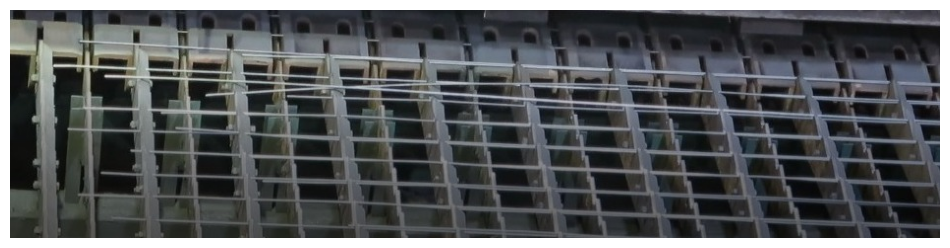

In [105]:
INPUT_IMAGE_PATH = 'vigas_crop.jpeg'

input_image_bgr = cv2.imread(INPUT_IMAGE_PATH)
sv.plot_image(input_image_bgr)

Objetivo: Segmentar las vigas del laminador

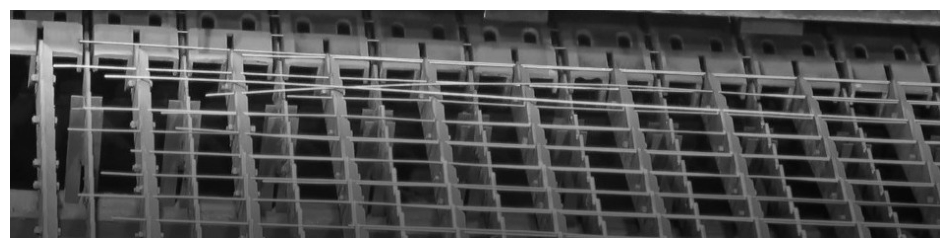

In [106]:
input_image_gray = cv2.cvtColor(input_image_bgr,cv2.COLOR_BGR2GRAY)
sv.plot_image(input_image_gray)

Binarizamos para ver si obtenemos algo usable:

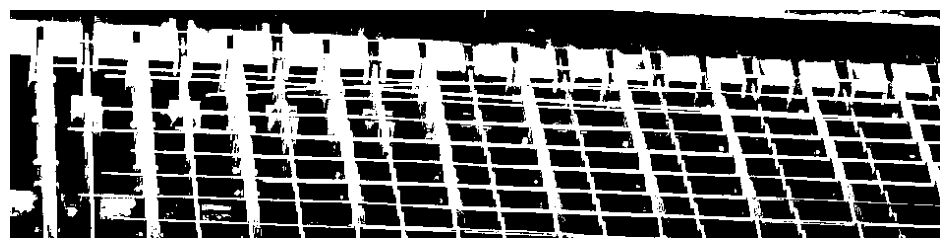

In [107]:
_, img_binary = cv2.threshold(input_image_gray, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
sv.plot_image(img_binary)

Probamos filtrar para obtener los pixeles de interes

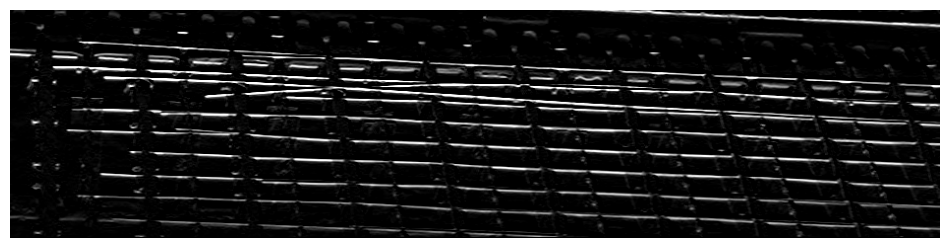

In [108]:
kernel_x = np.array([[1,1,1],[0,0,0],[-1,-1,-1]]) 
# sobel o prewit es indistinto mientras sea en la direccion correcta

enhanced_img = cv2.filter2D(input_image_gray, -1, kernel_x)
sv.plot_image(enhanced_img)

Hasta aca seguimos con una imagen en escala de grises pero con los bordes en X
"resaltados". Previo a la extraccion de esos bordes debemos mitigar el ruido. 
Luego podemos binarizar y realizar la extraccion.


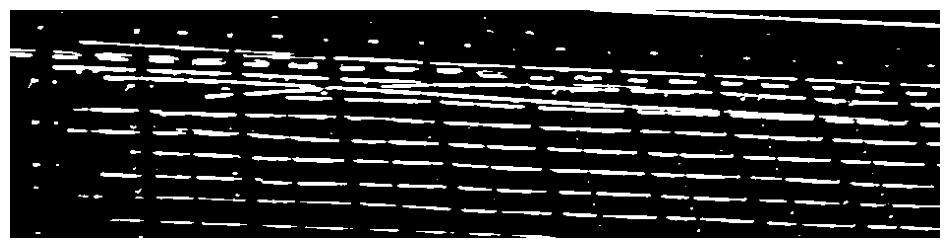

In [109]:
filtered_img = cv2.GaussianBlur(enhanced_img, (5, 5), 0)
_, binarized = cv2.threshold(filtered_img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
sv.plot_image(binarized)

Aplicamos procesamiento morfologico para extraer las vigas

[[1 1 1 1 1]]


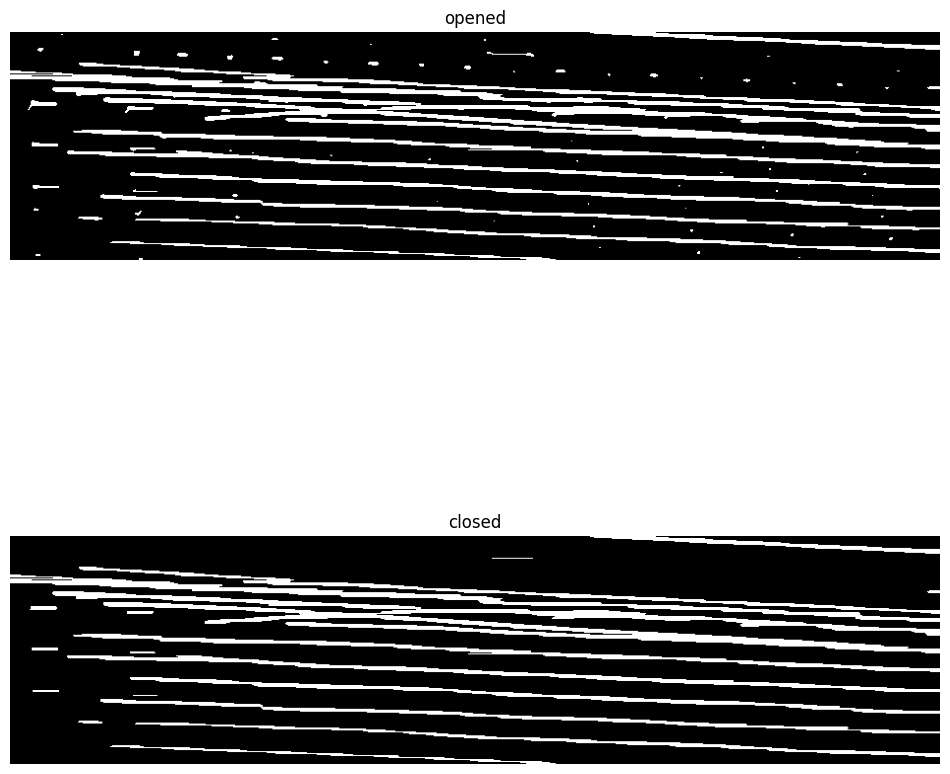

In [110]:
ELEM_LEN_PX = 5
struct_elem = cv2.getStructuringElement(cv2.MORPH_RECT, (ELEM_LEN_PX, 1))
print(struct_elem)

img_open = cv2.morphologyEx(binarized, cv2.MORPH_CLOSE, struct_elem, iterations = 8)
img_closed = cv2.morphologyEx(img_open, cv2.MORPH_OPEN, struct_elem, iterations = 4)
sv.plot_images_grid(
    [img_open, img_closed], titles=["opened", "closed"], grid_size=(2, 1))

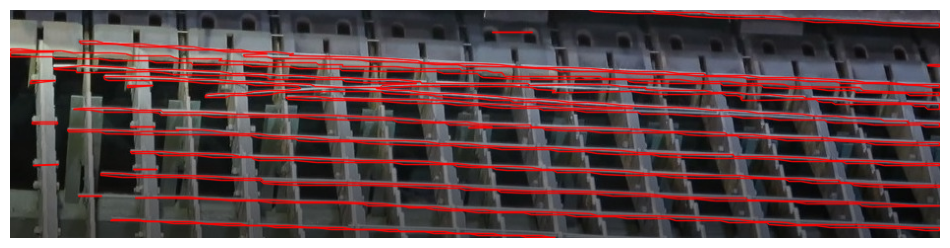

In [111]:
contours, _ = cv2.findContours(img_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_TC89_L1)

img2show = input_image_bgr.copy()

cv2.drawContours(img2show, contours, -1, (0,0,255), 	lineType = cv2.LINE_AA)
sv.plot_image(img2show)

A partir de un analisis heuristico podemos eliminar contornos demasiado cortos:

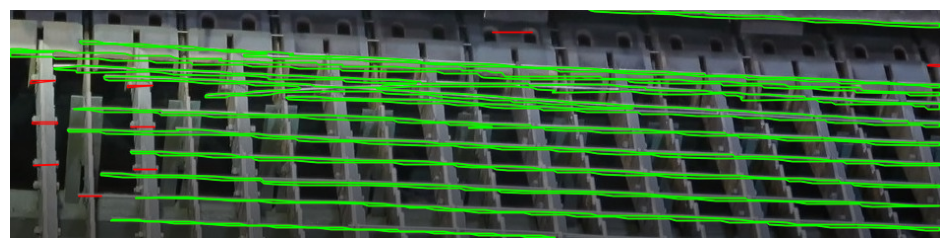

In [114]:
LEN_THRESHOLD = 25
valid_contours = [ctr for ctr in contours if len(ctr) > LEN_THRESHOLD]
cv2.drawContours(img2show, valid_contours, -1, (0, 255, 0), lineType = cv2.LINE_AA,)
sv.plot_image(img2show)